# AT&T Spam Detector

Contexte : AT&T, l'un des principaux opérateurs telecoms aux États-Unis, recoit des millions de SMS chaque jour. Une part significative de ces messages sont des spams — messages frauduleux ou publicitaires non sollicites. Les SMS sont des données textuelles non structurées : pas de schema fixe, longueur variable, vocabulaire informel et en constante evolution.

Objectif : Construire un detecteur de spam capable de classifier automatiquement un SMS comme spam ou ham (legitime) a partir de son contenu textuel uniquement.

Approche : Comparaison de deux architectures deep learning — un LSTM bidirectionnel entraine from scratch et un modèle DistilBERT pré-entraîné (transfer learning).

## 1. Chargement et EDA

### 1.1 Imports

In [1]:
import json
import re
import warnings
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset

warnings.filterwarnings("ignore")

# Reproductibilite
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Theme dark pour les graphiques (diaporama)
plt.style.use('dark_background')
ACCENT = '#009FDB'  # Bleu AT&T


### 1.2 Chargement des données

In [2]:
# Chargement du dataset et renommage des colonnes
df = pd.read_csv(
    '../data/spam.csv', encoding='latin-1',
)
df = df[['v1', 'v2']].rename(
    columns={'v1': 'label', 'v2': 'text'},
)
df['target'] = (df['label'] == 'spam').astype(int)

print(f"Dataset : {df.shape[0]} SMS")
df.head()

Dataset : 5572 SMS


,label,text,target
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


### 1.3 Exploration des données

In [3]:
# Repartition des classes
print(df['label'].value_counts())
print(f"\nRatio spam : {df['target'].mean():.1%}")

label
ham     4825
spam     747
Name: count, dtype: int64

Ratio spam : 13.4%


Visualisation de la distribution des classes et de la
longueur des SMS.

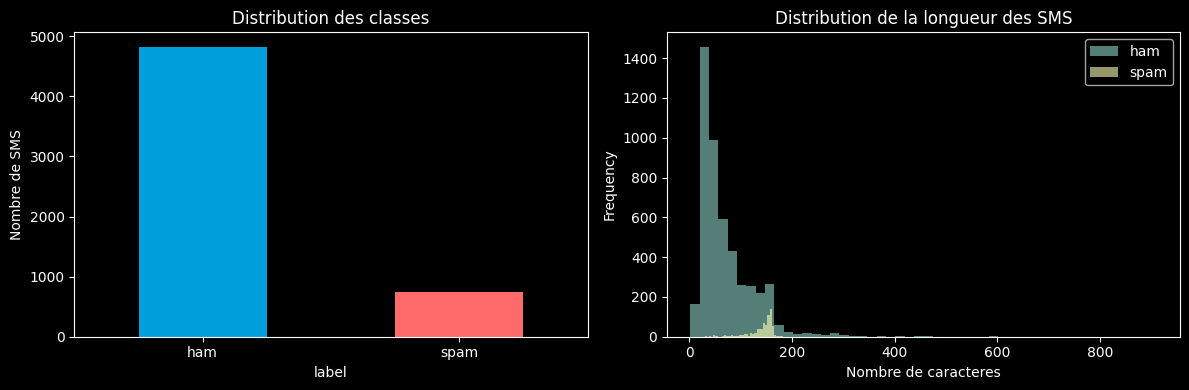

In [4]:
# Distribution des classes et longueur des SMS
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['label'].value_counts().plot(
    kind='bar', ax=axes[0],
    color=['#009FDB', '#FF6B6B'],
)
axes[0].set_title('Distribution des classes')
axes[0].set_ylabel('Nombre de SMS')
axes[0].tick_params(axis='x', rotation=0)

df['text_len'] = df['text'].str.len()
df.groupby('label')['text_len'].plot(
    kind='hist', alpha=0.6, bins=50,
    ax=axes[1], legend=True,
)
axes[1].set_title('Distribution de la longueur des SMS')
axes[1].set_xlabel('Nombre de caracteres')

plt.tight_layout()
plt.savefig(
    '../assets/images/eda_distribution.png',
    dpi=150, bbox_inches='tight',
)
plt.show()

Dataset déséquilibre : ~13% de spam contre ~87% de ham.
Les spams sont globalement plus longs que les messages
légitimes. Ce déséquilibre impose d'utiliser le F1-score
plutot que l'accuracy comme métrique principale.

## 2. Preprocessing

In [5]:
def clean_text(text):
    """Nettoyage : minuscules, suppression URLs, caracteres speciaux."""
    text = text.lower()
    # Suppression des URLs
    text = re.sub(r'http\S+', '', text)
    # Conservation lettres + espaces uniquement
    text = re.sub(r'[^a-z\s]', '', text)
    # Normalisation des espaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text


df['clean_text'] = df['text'].apply(clean_text)
df[['text', 'clean_text']].head()

,text,clean_text
0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...
3,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...


Split stratifié avant toute transformation pour éviter
le data leakage.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'], df['target'],
    test_size=0.2, random_state=SEED,
    stratify=df['target'],
)

print(f"Train : {len(X_train)} | Test : {len(X_test)}")
print(
    f"Ratio spam train : {y_train.mean():.1%}"
    f" | test : {y_test.mean():.1%}"
)

Train : 4457 | Test : 1115
Ratio spam train : 13.4% | test : 13.4%


Pas de data augmentation — le dataset est petit (5 572 SMS) et déséquilibre (13% spam). On pourrait compenser avec du synonym replacement ou de la back-translation, mais ca pose probleme ici. Les SMS font ~70 caracteres en mediane : remplacer un seul mot peut changer le sens. Le transfer learning compense deja le manque de données (DistilBERT a vu des milliards de tokens). Et pour le LSTM, le `pos_weight` de la loss gere le déséquilibre directement. Si les performances avaient ete insuffisantes, on aurait explore cette piste.

## 3. Modele 1 : LSTM

Le LSTM (Long Short-Term Memory) est un reseau récurrent conçu pour les données séquentielles. Contrairement a un reseau classique ou convolutionnel, il lit le texte mot par mot en conservant une mémoire des mots précédents. Sa variante bidirectionnelle lit le texte dans les deux sens, captant le contexte complet de chaque mot.

Architecture : embedding (128 dim), 2 couches LSTM bidirectionnelles (128 units), global average pooling, couche dense de sortie (1 neurone, classification binaire).

In [7]:
# Vocabulaire construit sur le train set uniquement
word_counts = Counter()
for text in X_train:
    word_counts.update(text.split())

# Filtrage : mots apparaissant au moins 2 fois
vocab = {
    word: idx + 2
    for idx, (word, count)
    in enumerate(word_counts.most_common())
    if count >= 2
}
vocab['<PAD>'] = 0
vocab['<UNK>'] = 1
VOCAB_SIZE = len(vocab)

print(f"Taille du vocabulaire : {VOCAB_SIZE}")

Taille du vocabulaire : 3450


Tokenisation et padding des séquences pour le LSTM.

In [8]:
# Longueur maximale des sequences
MAX_LEN = 150


def text_to_sequence(text, vocab, max_len):
    """Convertit un texte en sequence d'indices avec padding."""
    tokens = [
        vocab.get(w, 1) for w in text.split()
    ]
    if len(tokens) < max_len:
        tokens += [0] * (max_len - len(tokens))
    else:
        tokens = tokens[:max_len]
    return tokens


X_train_seq = torch.tensor(
    [
        text_to_sequence(t, vocab, MAX_LEN)
        for t in X_train
    ],
    dtype=torch.long,
)
X_test_seq = torch.tensor(
    [
        text_to_sequence(t, vocab, MAX_LEN)
        for t in X_test
    ],
    dtype=torch.long,
)
y_train_t = torch.tensor(
    y_train.values, dtype=torch.float32,
)
y_test_t = torch.tensor(
    y_test.values, dtype=torch.float32,
)

print(f"Shape train : {X_train_seq.shape}")

Shape train : torch.Size([4457, 150])


Création du Dataset PyTorch et des DataLoaders.

In [9]:
class SpamDataset(Dataset):
    """Dataset PyTorch pour les sequences tokenisees."""

    def __init__(self, sequences, labels):
        self.sequences = sequences
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]


BATCH_SIZE = 32
train_loader = DataLoader(
    SpamDataset(X_train_seq, y_train_t),
    batch_size=BATCH_SIZE, shuffle=True,
)
test_loader = DataLoader(
    SpamDataset(X_test_seq, y_test_t),
    batch_size=BATCH_SIZE,
)

Définition de l'architecture du LSTM bidirectionnel.

In [10]:
class LSTMSpamDetector(nn.Module):
    """LSTM bidirectionnel avec global average pooling."""

    def __init__(
        self, vocab_size, embed_dim,
        hidden_dim, dropout=0.5,
    ):
        super().__init__()
        self.embedding = nn.Embedding(
            vocab_size, embed_dim, padding_idx=0,
        )
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim, num_layers=2,
            batch_first=True, dropout=dropout,
            bidirectional=True,
        )
        self.dropout = nn.Dropout(dropout)
        # *2 car bidirectionnel
        self.fc = nn.Linear(hidden_dim * 2, 1)

    def forward(self, x):
        embedded = self.embedding(x)
        lstm_out, _ = self.lstm(embedded)
        # Global average pooling sur la sequence
        pooled = lstm_out.mean(dim=1)
        out = self.dropout(pooled)
        return self.fc(out).squeeze(1)


model_lstm = LSTMSpamDetector(
    VOCAB_SIZE, embed_dim=128, hidden_dim=64,
)
print(model_lstm)
n_params = sum(
    p.numel() for p in model_lstm.parameters()
)
print(f"Parametres : {n_params:,}")

LSTMSpamDetector(
  (embedding): Embedding(3450, 128, padding_idx=0)
  (lstm): LSTM(128, 64, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)
Parametres : 640,385


**Fonction de cout : BCEWithLogitsLoss**

On utilise BCEWithLogitsLoss parce que le LSTM produit un seul logit en sortie — c'est de la classification binaire. Cette loss combine sigmoid + binary cross-entropy en une seule operation, ce qui est plus stable numériquement. Le parametre `pos_weight=3.0` pondere la classe spam 3 fois plus fort pour compenser le déséquilibre. Le vrai ratio est 6.5, mais c'est trop agressif — ca genere trop de faux positifs. 3.0 est un compromis. Quant a la MSE, c'est une loss de regression : elle ne penalise pas assez les erreurs de classification et ne produit pas de probabilites calibrees.

Entrainement du LSTM avec BCEWithLogitsLoss pondérée.

In [11]:
# pos_weight compense le desequilibre des classes
pos_weight = torch.tensor([3.0])
criterion = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight,
)
optimizer = torch.optim.Adam(
    model_lstm.parameters(), lr=2e-3,
)
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer, step_size=5, gamma=0.5,
)

EPOCHS = 20
train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    # Phase d'entrainement
    model_lstm.train()
    epoch_loss = 0
    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()
        output = model_lstm(x_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            model_lstm.parameters(), 1.0,
        )
        optimizer.step()
        epoch_loss += loss.item()
    train_losses.append(
        epoch_loss / len(train_loader),
    )
    scheduler.step()

    # Phase d'evaluation
    model_lstm.eval()
    val_loss = 0
    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            output = model_lstm(x_batch)
            val_loss += criterion(
                output, y_batch,
            ).item()
    val_losses.append(
        val_loss / len(test_loader),
    )

    if (epoch + 1) % 5 == 0:
        print(
            f"Epoch {epoch + 1}/{EPOCHS} "
            f"- Train: {train_losses[-1]:.4f} "
            f"- Val: {val_losses[-1]:.4f}"
        )

Epoch 5/20 - Train: 0.0707 - Val: 0.1741
Epoch 10/20 - Train: 0.0248 - Val: 0.2079
Epoch 15/20 - Train: 0.0182 - Val: 0.2490
Epoch 20/20 - Train: 0.0103 - Val: 0.2358


Courbes de loss pour détecter l'overfitting.

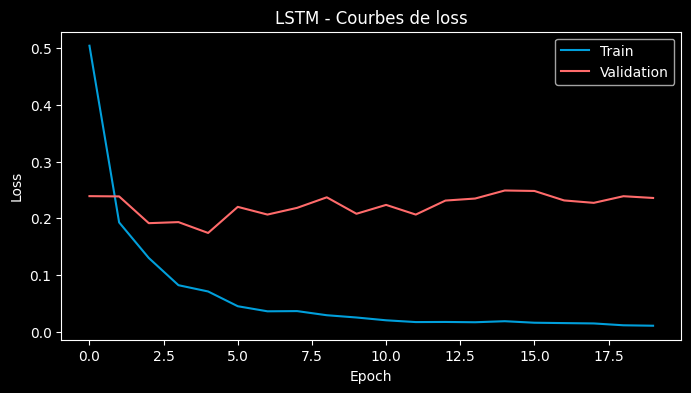

In [12]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train', color='#009FDB')
plt.plot(val_losses, label='Validation', color='#FF6B6B')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('LSTM - Courbes de loss')
plt.legend()
plt.savefig(
    '../assets/images/lstm_loss.png',
    dpi=150, bbox_inches='tight',
)
plt.show()

Evaluation sur le test set et rapport de classification.

In [13]:
# Predictions sur le test set
model_lstm.eval()
all_preds = []
with torch.no_grad():
    for x_batch, _ in test_loader:
        logits = model_lstm(x_batch)
        preds = (
            (torch.sigmoid(logits) > 0.5).int()
        )
        all_preds.extend(preds.tolist())

y_pred_lstm = np.array(all_preds)

print("=== LSTM - Resultats ===")
print(
    "Accuracy : "
    f"{accuracy_score(y_test, y_pred_lstm):.4f}"
)
print(
    "F1-score (spam) : "
    f"{f1_score(y_test, y_pred_lstm):.4f}"
)
print()
print(classification_report(
    y_test, y_pred_lstm,
    target_names=['ham', 'spam'],
))

=== LSTM - Resultats ===
Accuracy : 0.9785
F1-score (spam) : 0.9172

              precision    recall  f1-score   support

         ham       0.98      0.99      0.99       966
        spam       0.94      0.89      0.92       149

    accuracy                           0.98      1115
   macro avg       0.96      0.94      0.95      1115
weighted avg       0.98      0.98      0.98      1115



Matrice de confusion du LSTM.

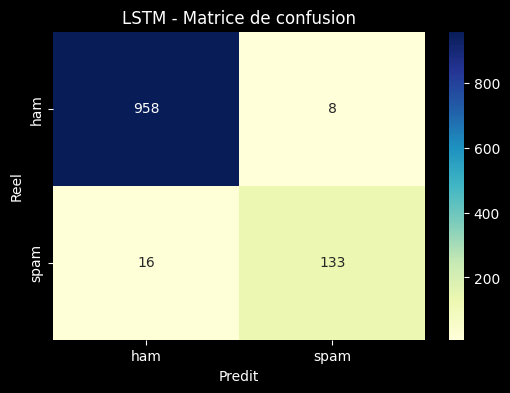

In [14]:
cm_lstm = confusion_matrix(y_test, y_pred_lstm)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_lstm, annot=True, fmt='d',
    cmap='YlGnBu',
    xticklabels=['ham', 'spam'],
    yticklabels=['ham', 'spam'],
)
plt.title('LSTM - Matrice de confusion')
plt.ylabel('Reel')
plt.xlabel('Predit')
plt.savefig(
    '../assets/images/lstm_confusion_matrix.png',
    dpi=150, bbox_inches='tight',
)
plt.show()

**Interpretation LSTM :** Le modèle atteint 97.85%
d'accuracy et un F1-score de 0.917 sur la classe spam.
La val loss augmente après l'epoch 5 (signe d'overfitting
léger). Le recall de 0.893 indique que ~11% des spams
passent a travers le filtre. Performances solides pour un
modèle a ~640k parametres entraine from scratch.

## 4. Modele 2 : DistilBERT

DistilBERT : version allégée de BERT (66M parametres),
pré-entraîné sur un large corpus anglais. On fine-tune
les 2 dernières couches transformer + le classifieur pour
adapter le modèle a notre tache de detection de spam.

In [15]:
from transformers import (
    DistilBertForSequenceClassification,
    DistilBertTokenizer,
)
from torch.optim import AdamW

# Chargement du modele et du tokenizer pre-entraines
tokenizer = DistilBertTokenizer.from_pretrained(
    'distilbert-base-uncased',
)
model_bert = (
    DistilBertForSequenceClassification.from_pretrained(
        'distilbert-base-uncased', num_labels=2,
    )
)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 8281.12it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Encodage des textes avec le tokenizer DistilBERT.

In [16]:
# Textes bruts (le tokenizer gere ponctuation/majuscules)
X_train_raw = df.loc[
    X_train.index, 'text',
].tolist()
X_test_raw = df.loc[
    X_test.index, 'text',
].tolist()

train_encodings = tokenizer(
    X_train_raw, truncation=True,
    padding=True, max_length=128,
    return_tensors='pt',
)
test_encodings = tokenizer(
    X_test_raw, truncation=True,
    padding=True, max_length=128,
    return_tensors='pt',
)

Dataset PyTorch et DataLoaders pour DistilBERT.

In [17]:
class BertSpamDataset(Dataset):
    """Dataset PyTorch pour les encodages DistilBERT."""

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {
            key: val[idx]
            for key, val
            in self.encodings.items()
        }
        item['labels'] = torch.tensor(
            self.labels[idx], dtype=torch.long,
        )
        return item

    def __len__(self):
        return len(self.labels)


train_bert_loader = DataLoader(
    BertSpamDataset(
        train_encodings, y_train.values,
    ),
    batch_size=16, shuffle=True,
)
test_bert_loader = DataLoader(
    BertSpamDataset(
        test_encodings, y_test.values,
    ),
    batch_size=16,
)

Freeze des couches basses pour le fine-tuning partiel.

In [18]:
# Freeze : embeddings + 4 premiers transformers
# Seules les 2 dernieres couches + classifieur
for param in (
    model_bert.distilbert.embeddings.parameters()
):
    param.requires_grad = False
for layer in list(
    model_bert.distilbert.transformer.layer
)[:4]:
    for p in layer.parameters():
        p.requires_grad = False

trainable = sum(
    p.numel() for p in model_bert.parameters()
    if p.requires_grad
)
total_params = sum(
    p.numel() for p in model_bert.parameters()
)
print(
    f"Parametres entrainables : {trainable:,}"
    f" / {total_params:,}"
    f" ({trainable / total_params:.1%})"
)

Parametres entrainables : 14,767,874 / 66,955,010 (22.1%)


**Fonction de cout : CrossEntropyLoss**

DistilBertForSequenceClassification utilise CrossEntropyLoss par défaut avec `num_labels=2`. Le modèle a 2 neurones en sortie, un par classe. Pas besoin de `pos_weight` ici — le transfer learning gere bien le déséquilibre sans compensation explicite. Le modèle a deja appris a représenter le langage, il lui reste juste a distinguer spam et ham. On entraine avec AdamW (learning rate 2e-5, standard pour le fine-tuning BERT).

Entrainement avec AdamW et learning rate adapté au
fine-tuning.

In [19]:
optimizer_bert = AdamW(
    filter(
        lambda p: p.requires_grad,
        model_bert.parameters(),
    ),
    lr=2e-5,
)

# 3 epochs suffisent grace au pre-entrainement
EPOCHS_BERT = 3
bert_train_losses, bert_val_losses = [], []

for epoch in range(EPOCHS_BERT):
    # Phase d'entrainement
    model_bert.train()
    epoch_loss = 0
    for batch in train_bert_loader:
        optimizer_bert.zero_grad()
        outputs = model_bert(
            input_ids=batch['input_ids'],
            attention_mask=(
                batch['attention_mask']
            ),
            labels=batch['labels'],
        )
        outputs.loss.backward()
        optimizer_bert.step()
        epoch_loss += outputs.loss.item()
    bert_train_losses.append(
        epoch_loss / len(train_bert_loader),
    )

    # Phase d'evaluation
    model_bert.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in test_bert_loader:
            outputs = model_bert(
                input_ids=batch['input_ids'],
                attention_mask=(
                    batch['attention_mask']
                ),
                labels=batch['labels'],
            )
            val_loss += outputs.loss.item()
    bert_val_losses.append(
        val_loss / len(test_bert_loader),
    )

    print(
        f"Epoch {epoch + 1}/{EPOCHS_BERT} "
        f"- Train: {bert_train_losses[-1]:.4f} "
        f"- Val: {bert_val_losses[-1]:.4f}"
    )

Epoch 1/3 - Train: 0.1060 - Val: 0.0475
Epoch 2/3 - Train: 0.0287 - Val: 0.0373
Epoch 3/3 - Train: 0.0176 - Val: 0.0337


Courbes de loss pour visualiser la convergence.

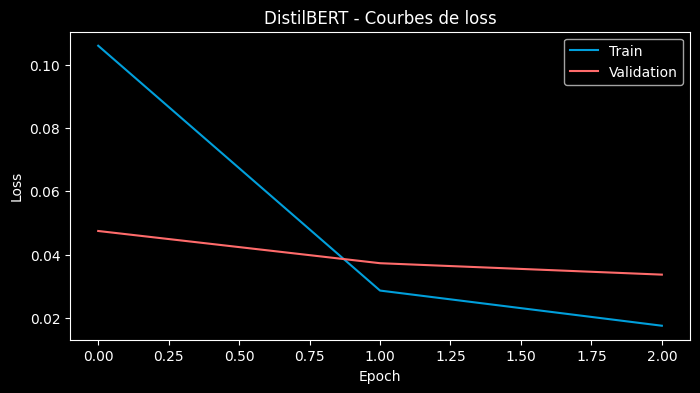

In [20]:
plt.figure(figsize=(8, 4))
plt.plot(bert_train_losses, label='Train', color='#009FDB')
plt.plot(bert_val_losses, label='Validation', color='#FF6B6B')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('DistilBERT - Courbes de loss')
plt.legend()
plt.savefig(
    '../assets/images/bert_loss.png',
    dpi=150, bbox_inches='tight',
)
plt.show()

Evaluation du modèle sur le test set.

In [21]:
# Predictions DistilBERT sur le test set
model_bert.eval()
all_preds_bert = []
with torch.no_grad():
    for batch in test_bert_loader:
        outputs = model_bert(
            input_ids=batch['input_ids'],
            attention_mask=(
                batch['attention_mask']
            ),
        )
        preds = torch.argmax(
            outputs.logits, dim=1,
        )
        all_preds_bert.extend(preds.tolist())

y_pred_bert = np.array(all_preds_bert)

print("=== DistilBERT - Resultats ===")
print(
    "Accuracy : "
    f"{accuracy_score(y_test, y_pred_bert):.4f}"
)
print(
    "F1-score (spam) : "
    f"{f1_score(y_test, y_pred_bert):.4f}"
)
print()
print(classification_report(
    y_test, y_pred_bert,
    target_names=['ham', 'spam'],
))

=== DistilBERT - Resultats ===
Accuracy : 0.9919
F1-score (spam) : 0.9693

              precision    recall  f1-score   support

         ham       0.99      1.00      1.00       966
        spam       0.99      0.95      0.97       149

    accuracy                           0.99      1115
   macro avg       0.99      0.98      0.98      1115
weighted avg       0.99      0.99      0.99      1115



Matrice de confusion DistilBERT.

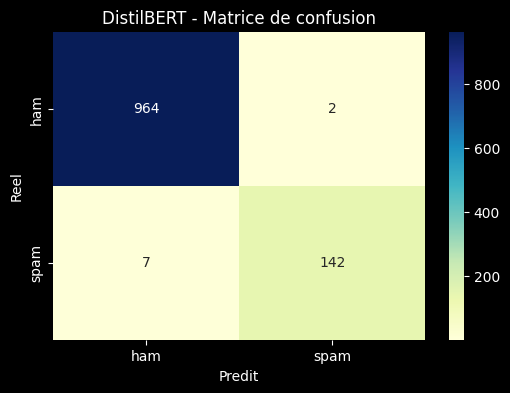

In [22]:
cm_bert = confusion_matrix(
    y_test, y_pred_bert,
)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_bert, annot=True, fmt='d',
    cmap='YlGnBu',
    xticklabels=['ham', 'spam'],
    yticklabels=['ham', 'spam'],
)
plt.title('DistilBERT - Matrice de confusion')
plt.ylabel('Reel')
plt.xlabel('Predit')
plt.savefig(
    '../assets/images/bert_confusion_matrix.png',
    dpi=150, bbox_inches='tight',
)
plt.show()

**Interpretation DistilBERT :** Le modèle atteint 99.19%
d'accuracy et un F1-score de 0.969 sur la classe spam.
La val loss diminue de maniere régulière sur les 3 epochs,
sans signe d'overfitting. La precision de 0.986 signifie
que tres peu de messages légitimes sont filtrés a tort
(2 faux positifs). Le recall de 0.953 montre que le modele
détecte la grande majorité des spams.

## 5. Comparaison et conclusion

In [23]:
# Tableau comparatif des deux modeles
results = pd.DataFrame({
    'Modele': ['LSTM', 'DistilBERT'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lstm),
        accuracy_score(y_test, y_pred_bert),
    ],
    'F1 (spam)': [
        f1_score(y_test, y_pred_lstm),
        f1_score(y_test, y_pred_bert),
    ],
    'Precision (spam)': [
        precision_score(y_test, y_pred_lstm),
        precision_score(y_test, y_pred_bert),
    ],
    'Recall (spam)': [
        recall_score(y_test, y_pred_lstm),
        recall_score(y_test, y_pred_bert),
    ],
})
results.round(4)

,Modele,Accuracy,F1 (spam),Precision (spam),Recall (spam)
0,LSTM,0.9785,0.9172,0.9433,0.8926
1,DistilBERT,0.9919,0.9693,0.9861,0.9530


Visualisation comparative des performances.

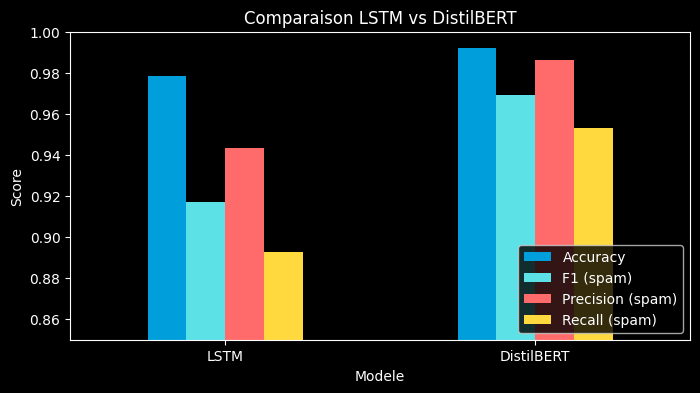

In [24]:
# Graphique comparatif
fig, ax = plt.subplots(figsize=(8, 4))
results.set_index('Modele')[
    [
        'Accuracy', 'F1 (spam)',
        'Precision (spam)', 'Recall (spam)',
    ]
].plot(
    kind='bar', ax=ax, rot=0,
    color=['#009FDB', '#5CE1E6', '#FF6B6B', '#FFD93D'],
)
ax.set_ylim(0.85, 1.0)
ax.set_title('Comparaison LSTM vs DistilBERT')
ax.set_ylabel('Score')
ax.legend(loc='lower right')
plt.savefig(
    '../assets/images/model_comparison.png',
    dpi=150, bbox_inches='tight',
)
plt.show()

### Conclusion business

| Modele | Accuracy | F1 (spam) | Precision | Recall |
|--------|----------|-----------|-----------|--------|
| LSTM | 97.85% | 0.917 | 0.943 | 0.893 |
| DistilBERT | 99.19% | 0.969 | 0.986 | 0.953 |

**Pourquoi le F1-score est la métrique clé :** Le dataset
est déséquilibre (13% de spam), donc l'accuracy seule serait
trompeuse (un modèle naïf "tout ham" atteindrait 87%).

**Analyse comparative :**
- **LSTM** (~640k parametres) : rapide a entraîner,
  performances solides. Overfitting léger après l'epoch 5.
  Le recall de 0.893 signifie que ~11% des spams ne sont
  pas détectés.
- **DistilBERT** (66M parametres, ~22% fine-tunes) : le
  transfer learning capte mieux les nuances sémantiques.
  3 epochs suffisent. Pas d'overfitting. Precision de
  0.986 = tres peu de faux positifs.

**Recommandation pour AT&T :** DistilBERT surpasse le LSTM
sur toutes les metriques. En production, la haute precision
(0.986) est cruciale : bloquer un SMS legitime (faux positif)
est plus dommageable pour l'experience client que laisser
passer un spam. DistilBERT minimise ce risque tout en
maintenant un recall eleve (0.953). Le transfer learning est
particulierement pertinent lorsque le dataset est limite
(5 572 exemples).

In [25]:
# Sauvegarde des resultats au format JSON
lstm_results = {
    "accuracy": round(
        accuracy_score(y_test, y_pred_lstm), 4,
    ),
    "f1": round(
        f1_score(y_test, y_pred_lstm), 4,
    ),
    "precision": round(
        precision_score(y_test, y_pred_lstm), 4,
    ),
    "recall": round(
        recall_score(y_test, y_pred_lstm), 4,
    ),
    "cm": confusion_matrix(
        y_test, y_pred_lstm,
    ).tolist(),
    "train_losses": train_losses,
    "val_losses": val_losses,
}

bert_results = {
    "accuracy": round(
        accuracy_score(y_test, y_pred_bert), 4,
    ),
    "f1": round(
        f1_score(y_test, y_pred_bert), 4,
    ),
    "precision": round(
        precision_score(y_test, y_pred_bert), 4,
    ),
    "recall": round(
        recall_score(y_test, y_pred_bert), 4,
    ),
    "cm": confusion_matrix(
        y_test, y_pred_bert,
    ).tolist(),
    "train_losses": bert_train_losses,
    "val_losses": bert_val_losses,
}

with open('../_lstm_results.json', 'w') as f:
    json.dump(lstm_results, f)
with open('../_bert_results.json', 'w') as f:
    json.dump(bert_results, f)

print(
    "Resultats sauvegardes dans"
    " _lstm_results.json et _bert_results.json"
)

Resultats sauvegardes dans _lstm_results.json et _bert_results.json
